# Capstone: Define and Solve an ML Problem

In [1]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
import time

## Overview


In this capstone assignment, I will follow the machine learning life cycle and implement a supervised learning model, along with a neural network, to solve a predictive problem.

## Part 1: Data Set and Build DataFrame

**Airbnb NYC Listings Data** (`airbnbListingsData.csv`)
This data set contains information about Airbnb listings in New York City. I will use it to predict whether a listing is high-priced. The data set includes a new `price_category` column that classifies each listing as either "high price" or "low price" based on whether the listing’s price falls above or below the 75th percentile of all listing prices. Listings at or above the 75th percentile are labeled as `high`, while the remaining listings are labeled as `low`. I will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation. 

In [ ]:
# file path for data set
airbnb_filename = os.path.join(os.getcwd(), "data_capstone", "airbnbListingsData.csv")

# load dataset and save it to df
df = pd.read_csv(airbnb_filename)

df.head()

,name,description,neighborhood_overview,host_name,host_location,host_about,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,...,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,n_host_verifications,price_category
0,Skylit Midtown Castle,"Beautiful, spacious skylit studio in the heart...",Centrally located in the heart of Manhattan ju...,Jennifer,"New York, New York, United States",A New Yorker since 2000! My passion is creatin...,0.80,0.17,True,8.0,...,4.86,4.41,False,3,3,0,0,0.33,9,low
1,"Whole flr w/private bdrm, bath & kitchen(pls r...","Enjoy 500 s.f. top floor in 1899 brownstone, w...",Just the right mix of urban center and local n...,LisaRoxanne,"New York, New York, United States",Laid-back Native New Yorker (formerly bi-coast...,0.09,0.69,True,1.0,...,4.71,4.64,False,1,1,0,0,4.86,6,low
2,"Spacious Brooklyn Duplex, Patio + Garden",We welcome you to stay in our lovely 2 br dupl...,NaN,Rebecca,"Brooklyn, New York, United States","Rebecca is an artist/designer, and Henoch is i...",1.00,0.25,True,1.0,...,4.50,5.00,False,1,1,0,0,0.02,3,high
3,Large Furnished Room Near B'way,Please don’t expect the luxury here just a bas...,"Theater district, many restaurants around here.",Shunichi,"New York, New York, United States",I used to work for a financial industry but no...,1.00,1.00,True,1.0,...,4.87,4.36,False,1,0,1,0,3.68,4,low
4,Cozy Clean Guest Room - Family Apt,"Our best guests are seeking a safe, clean, spa...",Our neighborhood is full of restaurants and ca...,MaryEllen,"New York, New York, United States",Welcome to family life with my oldest two away...,NaN,NaN,True,1.0,...,4.94,4.92,False,1,0,1,0,0.87,7,low


## Part 2: Define My ML Problem

1. Which data set did I choose?
2. What is my label? What am I predicting?
3. What features do I plan to use? (This list may change after I explore my data.)
5. Why does this problem matter?

1. I chose the Airbnb data set.
2. The label is price_category. I am predicting whether the listing's price falls at or above 75th percentile (high), or not (low).
3. Some features that I plan to use are review_scores_value, host_is_superhost, room_type, bedrooms, amenities, and neighborhood_group_cleansed.
4. This problem matters because it will determine what locations that Trove Analytics wants to invest their money in. This means that my model's predictions on high valued properties can determine whether or not Trove Analytics purchases them.

## Part 3: Understand My Data

### Class Imbalance

<AxesSubplot:xlabel='price_category', ylabel='Count'>

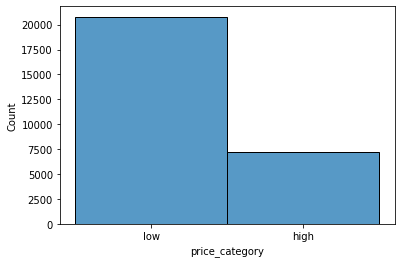

In [3]:
# histplot to see class distribution
sns.histplot(data=df, x=df['price_category'])

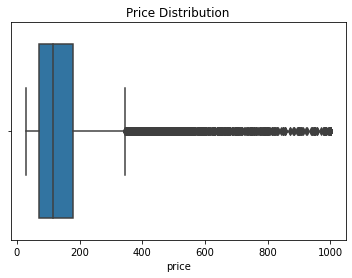

In [4]:
# boxplot to see outliers
sns.boxplot(x=df['price'])
plt.title('Price Distribution')
plt.show()

### Inspect and Analyze My Data

In [5]:
df.describe(include='all')

,name,description,neighborhood_overview,host_name,host_location,host_about,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,...,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,n_host_verifications,price_category
count,28017,27452,18206,28022,27962,17077,16179.000000,16909.000000,28022,28022.000000,...,28022.000000,28022.000000,28022,28022.000000,28022.000000,28022.000000,28022.000000,28022.000000,28022.000000,28022
unique,27386,25952,15800,7566,1364,11962,NaN,NaN,1,NaN,...,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,2
top,Water View King Bed Hotel Room,Welcome to UNTITLED (Adj.) at 3 Freeman Alley!...,We're located in a safe and quiet residential ...,Karen,"New York, New York, United States",I’m a New York native that loves to eat & enjo...,NaN,NaN,True,NaN,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,low
freq,27,61,34,246,16059,191,NaN,NaN,28022,NaN,...,NaN,NaN,20382,NaN,NaN,NaN,NaN,NaN,NaN,20785
mean,NaN,NaN,NaN,NaN,NaN,NaN,0.906901,0.791953,NaN,14.554778,...,4.750393,4.647670,NaN,9.581900,5.562986,3.902077,0.048283,1.758325,5.169510,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,0.227282,0.276732,NaN,120.721287,...,0.415717,0.518023,NaN,32.227523,26.121426,17.972386,0.442459,4.446143,2.028497,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,0.000000,...,0.000000,0.000000,NaN,1.000000,0.000000,0.000000,0.000000,0.010000,1.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,0.940000,0.680000,NaN,1.000000,...,4.670000,4.550000,NaN,1.000000,0.000000,0.000000,0.000000,0.130000,4.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.910000,NaN,1.000000,...,4.880000,4.780000,NaN,1.000000,1.000000,0.000000,0.000000,0.510000,5.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,NaN,3.000000,...,5.000000,5.000000,NaN,3.000000,1.000000,1.000000,0.000000,1.830000,7.000000,NaN


all columns:
 ['name', 'description', 'neighborhood_overview', 'host_name', 'host_location', 'host_about', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_listings_count', 'host_total_listings_count', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood_group_cleansed', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'instant_bookable', 'calculated_host_listings_count', 'calculated_host_listings_count_ent

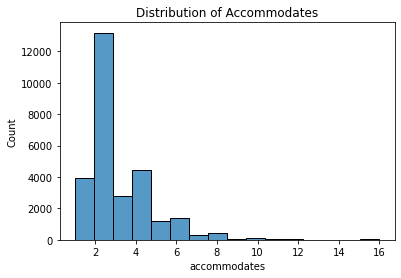

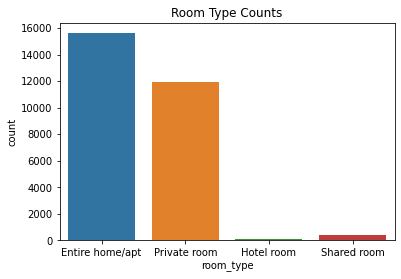

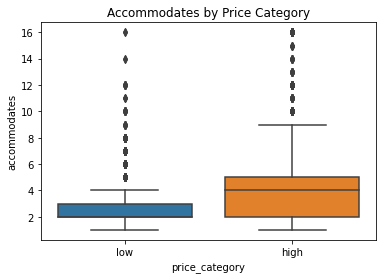

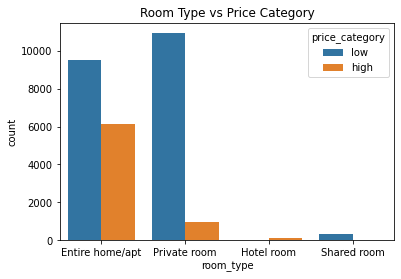

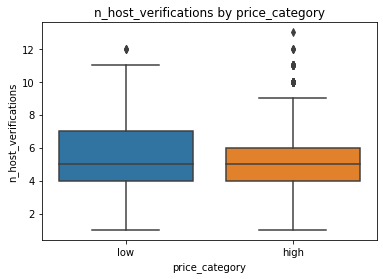

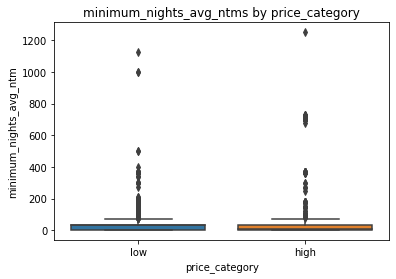

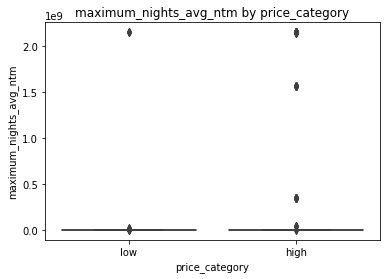

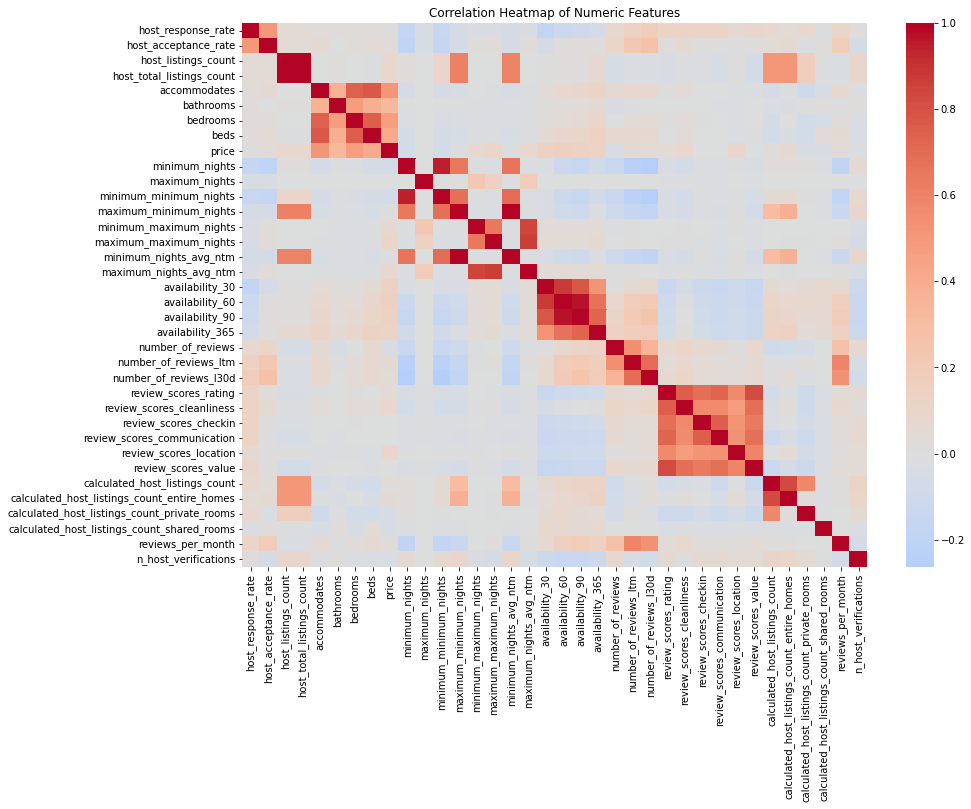

                             review_scores_rating  review_scores_cleanliness  \
review_scores_rating                     1.000000                   0.758213   
review_scores_cleanliness                0.758213                   1.000000   
review_scores_checkin                    0.688152                   0.571335   
review_scores_communication              0.727749                   0.567027   
review_scores_location                   0.574464                   0.480354   
review_scores_value                      0.820631                   0.687473   

                             review_scores_checkin  \
review_scores_rating                      0.688152   
review_scores_cleanliness                 0.571335   
review_scores_checkin                     1.000000   
review_scores_communication               0.756146   
review_scores_location                    0.528719   
review_scores_value                       0.644369   

                             review_scores_communication  \


In [ ]:
# print all column names
print('all columns:\n', df.columns.tolist())

# computer the number of nan values in each column
nan_count = np.sum(df.isnull(), axis=0)

# print column names that have nan values
condition = nan_count != 0 # look for all columns with missing values
nan_cols = nan_count[condition].index.tolist()
print('\nnan columns:\n', nan_cols)

# print types of columns that have nan values
nan_cols_types = df[nan_cols].dtypes
print('\nnan columns types:\n', nan_cols_types)

# print counts of nan values per column with at least one
print('\nnan columns nan counts:\n', nan_count[nan_cols])

# print unique value counts of all columns
unique_counts = df.nunique().sort_values()
print('\nunique value counts:\n', unique_counts)

# histplot to see distribution in 'accommodates'
sns.histplot(df['accommodates'], bins=16)
plt.title('Distribution of Accommodates')
plt.show()

# categorical bar chart to see distribution in 'room_type'
sns.countplot(x=df['room_type'])
plt.title('Room Type Counts')
plt.show()

# view if 'accomodates' has a relationship with 'price_category'
sns.boxplot(x='price_category', y='accommodates', data=df)
plt.title('Accommodates by Price Category')
plt.show()

# view if 'room_type' has a relationship with 'price_category'
sns.countplot(x='room_type', hue='price_category', data=df)
plt.title('Room Type vs Price Category')
plt.show()

# view if 'n_host_verifications' has a relationship with 'price_category'
sns.boxplot(x='price_category', y='n_host_verifications', data=df)
plt.title('n_host_verifications by price_category')
plt.show()

# view if 'minimum_nights_avg_ntm' has a relationship with 'price_category'
sns.boxplot(x='price_category', y='minimum_nights_avg_ntm', data=df)
plt.title('minimum_nights_avg_ntms by price_category')
plt.show()

# view if 'maximum_nights_avg_ntm' has a relationship with 'price_category'
sns.boxplot(x='price_category', y='maximum_nights_avg_ntm', data=df)
plt.title('maximum_nights_avg_ntm by price_category')
plt.show()


# correlation heatmap for numeric features
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

# check review_scores columns specifically for multicollinearity
review_cols = ['review_scores_rating', 'review_scores_cleanliness', 'review_scores_checkin',
               'review_scores_communication', 'review_scores_location', 'review_scores_value']
print(df[review_cols].corr())

### EDA Summary

In the markdown cell below, I summarize the key findings from my data exploration.

Missing Values:
There are nine columns with missing values. Five of them are of type object. Name and host_location likely will not make meaningful contributions to the model. Description, neighborhood_overview, and host_about may be beneficial if converted into missing value indicators (i.e. has_description, has_neighborhood_overview, and has_host_about), but that may go beyond the scope of this course, so I will likely not use these columns in my model since they are open ended. Locations with more bedrooms likely cost more, so I may want to convert that using one-hot encoding. The other numeric columns with missing values are host_acceptance_rate, bedrooms, and beds. I will likely impute these using the median since all three are right-skewed.


Outliers:
There are several columns that appear to have outliers. Here are a few examples:
* host_listings_count
* minimum_nights
* calculated_host_listings_count
* reviews_per_month.

For these columns, I will likely winsorize them or apply a log transformation.


Redundant Columns:
It appears that there are some columns that serve the same, similar, or redundant purposes. Here are a few examples:
* 'host_listings_count' and 'host_total_listings_count'
* 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', and 'maximum_nights_avg_ntm'.
* 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', and 'calculated_host_listings_count_shared_rooms'


Irrelevant Columns:
* Columns with one value: host_is_superhost, host_has_profile_pic, host_identity_verified
* Open ended columns: name, description, neighborhood_overview, host_name, host_location, host_about, amenities
    * May be able to keep amenities by using one-hot encoding for key words
    
Class Imbalance:
The label 'price_category' is imbalanced. Almost 3/4 of the listings fall into the 'low' category, with the remaining 1/4 in the 'high' category. I may want to do random sampling in order to get even distributions or making sure I am using weights for classes.

Feature-Label Relationship:
'accommodates' and 'room_type' both show a relationship with price_category. In the accommodates vs. price_category boxplot, 'high' price listings have a noticeably higher median (4) and Q3  (9) for accommodates compared to 'low' price listings with a median of 2 and a Q3 of 4. The room_type vs. price_category plot shows 'Private' rooms skew heavily toward low price point, while 'Entire home/apt' is closer to evenly split. 'n_host_verifications' does not appear to have much of a relationship with 'price_category'. 'minimum_nights_avg_ntms' and 'maximum_nights_avg_ntms' appear to have little relationship with 'price_category'.

Multicollinearity:
The correlation heatmap shows that 'review_scores_rating' is highly correlated with the other review_scores columns (cleanliness, check, communication, location, and value). Since I am using logistic regression, I will drop 'review_scores_rating' and keep the more specific sub-category scores.

### Ethical Considerations:

1. What biases or ethical concerns might be present in my dataset?
2. Who could be harmed by a model that makes incorrect predictions on this data, and how?

1. The Airbnb dataset was taken from people who have used Airbnb in the past. This means that it excludes people who cannot afford to rent properties on Airbnb, which may cause the dataset to underepresent lower-income individuals and communities. The data also reflects whatever biases exist in Airbnb's current system. The following are some features that could serve as proxies for protected characteristics:
* neighbourhood_group_cleansed: can serve as a proxy for socioeconomic status and potentially race or ethnicity due to historical housing segregation
* host_name: could allow inference of a host's gender or ethnicity
* host_about and host_location: could reveal information about a host's background, language, or national origin

2. Hosts with properties in lower-income neighborhoods or neighborhoods with a high minority population could be systematically predicted into the 'low' price category, regardless of the actual quality of their listing. This would disproportionately harm hosts who are already at an economic disadvantage. The model could indirectly discriminate against minority hosts by consistently undervaluing their properties. Mispredicting a 'low' price could cause guests to overpay for a worse experience, while mispredicting a 'high' price could cause a host to lose potential bookings.

## Part 4: Prepare My Data

In [7]:
import scipy.stats as stats

In [8]:
# drop 'price' and irrelevant columns
irr_cols = ['price', 'name', 'n_host_verifications', 'description', 'neighborhood_overview', 'host_name', 'host_location', 'host_about', 'host_is_superhost', 'host_has_profile_pic', 'host_identity_verified',
            'minimum_nights_avg_ntm', 'minimum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights',
            'maximum_nights_avg_ntm', 'maximum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights',
            'review_scores_rating'
           ]
df_prep = df.drop(columns=irr_cols)

# make amentities_count column
df_prep['amenities_count'] = df['amenities'].apply(lambda x: len(x.split(',')) if isinstance(x, str) and x not in ['[]', ''] else 0)

# one-hot encode for some key amenities
key_amenities = ['Pool', 'Air conditioning', 'TV', 'Elevator', 'Gym', 'Wifi']
for amenity in key_amenities:
    col_name = f'has_{amenity.lower().replace(" ", "_")}'
    df_prep[col_name] = df['amenities'].str.contains(amenity, case=False, na=False).astype(int)
# drop original 'amenities' column
df_prep = df_prep.drop(columns=['amenities'])

# drop reduntant columns, keeping only one from each category if relevant
# keep: calculated_host_listings_count, availability_365, number_of_reviews
redundant_cols = ['host_total_listings_count', 'host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms',
                  'availability_30', 'availability_60', 'availability_90',
                  'number_of_reviews_ltm', 'number_of_reviews_l30d',
                 ]
df_prep = df_prep.drop(columns=redundant_cols)

# handle numeric missing values using median
numeric_missing = ['host_response_rate', 'host_acceptance_rate', 'bedrooms', 'beds']
for col in numeric_missing:
    df_prep[col] = df_prep[col].fillna(df_prep[col].median())

# handle outliers using winsorization
skewed_cols = ['calculated_host_listings_count', 'reviews_per_month']
for col in skewed_cols:
    df_prep[col] = np.array(stats.mstats.winsorize(df_prep[col], limits=[0.01, 0.01]))

# encode categorical features
categorical_cols = ['neighbourhood_group_cleansed', 'room_type']
df_prep = pd.get_dummies(df_prep, columns=categorical_cols, drop_first=True)

# encode boolean features
bool_cols = ['has_availability', 'instant_bookable']
for col in bool_cols:
    df_prep[col] = df_prep[col].astype(int)

# convert label to binary (high=True, low=False)
df_prep['price_category'] = np.where(df_prep['price_category'] == 'high', 1, 0)

# scale numeric columns using z-score
numeric_cols = ['host_response_rate', 'host_acceptance_rate', 'accommodates', 'bathrooms',
                'bedrooms', 'beds', 'availability_365', 'number_of_reviews',
                'review_scores_cleanliness', 'review_scores_checkin',
                'review_scores_communication', 'review_scores_location',
                'review_scores_value', 'calculated_host_listings_count',
                'reviews_per_month', 'amenities_count']
df_prep[numeric_cols] = df_prep[numeric_cols].apply(stats.zscore)

# confirm no missing values remain
print('remaining missing values:', df_prep.isnull().sum().sum())
print('shape:', df_prep.shape)
df_prep.head()


remaining missing values: 0
shape: (28022, 32)


,host_response_rate,host_acceptance_rate,accommodates,bathrooms,bedrooms,beds,has_availability,availability_365,number_of_reviews,review_scores_cleanliness,...,has_elevator,has_gym,has_wifi,neighbourhood_group_cleansed_Brooklyn,neighbourhood_group_cleansed_Manhattan,neighbourhood_group_cleansed_Queens,neighbourhood_group_cleansed_Staten Island,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,-0.818339,-3.004607,-1.007673,-0.337606,-0.440314,-0.555409,1,1.494669,0.291485,0.011584,...,0,0,1,0,1,0,0,0,0,0
1,-4.791198,-0.668378,0.067470,-0.337606,-0.440314,1.298622,1,0.458908,6.703791,-0.214944,...,0,0,1,1,0,0,0,0,0,0
2,0.300776,-2.645187,0.605041,0.849692,1.050381,0.371607,1,-0.051779,-0.525595,0.673742,...,0,0,1,1,0,0,0,0,0,0
3,0.300776,0.724374,-0.470102,-0.337606,-0.440314,-0.555409,1,0.444523,8.444528,-1.539261,...,0,0,1,0,1,0,0,0,1,0
4,0.300776,0.320027,-1.007673,-0.337606,-0.440314,-0.555409,1,-0.936492,1.534869,0.360088,...,1,0,1,0,1,0,0,0,1,0


### Data Preparation Summary:

Irrelevant Columns:
* 'price' - 'price_category' was directly derived from 'price', cannot use this as a feature
* 'name', 'description', 'neighborhood_overview', 'host_name', 'host_location', 'host_about': free-form text with no consistent structure
* 'host_is_superhost', 'host_has_profile_pic', 'host_identity_verified': only one unique value in each
* 'n_host_verifications': near zero correlation with label
* 'minimum_nights_avg_ntm', 'minimum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights': near zero correlation with label and redundant
* 'maximum_nights_avg_ntm', 'maximum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights':  near zero correlation with label and redundant
* 'review_scores_rating': high correlation with other review_score columns

Amenities Columns:
* added an 'amenities_count' column using 'amenities'
* one-hot encoded for key elements of 'amenities' that may hold a predictive value
* dropped original 'amenities' column

Redundant Columns:
* kept one representative column from each group:
    1. 'calculated_host_listings_count': verified count of host listings by Airbnb
    2. 'availability_365': captures same info in more complete time window, less sensitive to short-term fluctuations
    3. 'number_of_reviews': captures same info in more complete time window, less sensitive to short-term fluctuations
* dropped remaining redundant columns:
    1. 'host_total_listings_count', 'host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms'
    2. 'availability_30', 'availability_60', 'availability_90'
    3. 'number_of_reviews_ltm', 'number_of_reviews_l30d'

Columns with Missing Values:
* 'host_response_rate', 'host_acceptance_rate', 'bedrooms', 'beds': imputed missing values using the median

Winsorized Columns With Many Outliers:
* 'calculated_host_listings_count', 'reviews_per_month': winsorized using the 1st & 99th percentiles

Categorical Columns:
* 'neighbourhood_group_cleansed', 'room_type': one-hot encoded, then dropped original columns

Boolean Columns:
* 'has_availability', 'instant_bookable': converted to binary

Label:
* 'price_category': converted to binary (high=1, low=0)

Scale Numeric Columns:
* 'host_response_rate', 'host_acceptance_rate', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'availability_365', 'number_of_reviews', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'calculated_host_listings_count', 'reviews_per_month', 'amenities_count': applied z-score standardization to all the continuous numeric columns left in the dataset

## Part 5: Train, Test, Evaluate, and Improve a Traditional Machine Learning Model

In [ ]:
# create labeled examples from the dataset
X = df_prep.drop(columns='price_category')
y = df_prep['price_category']

In [ ]:
# create training and test sets out of the labeled examples 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=1234)
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (21016, 31)
X_test shape: (7006, 31)
y_train shape: (21016,)
y_test shape: (7006,)


In [ ]:
# train, test and evaluate model
model = LogisticRegression(class_weight='balanced', max_iter=3000)
model.fit(X_train, y_train)

class_label_predictions = model.predict(X_test)

acc_score = accuracy_score(y_test, class_label_predictions)
f1 = f1_score(y_test, class_label_predictions, average='binary')

print('Baseline Logistic Regression Accuracy:', acc_score)
print('Baseline Logistic Regression F1 Score:', f1)

Baseline Logistic Regression Accuracy: 0.7590636597202398
Baseline Logistic Regression F1 Score: 0.6268788682581786


In [ ]:
# perform model selection through grid search cross-validation (GridSearchCV)
# to identify optimal hyperparameter values for my model
cs=[10**i for i in range(-5,5)]
param_grid = {'C': cs, 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}

grid_search = GridSearchCV(model, param_grid, scoring='f1', cv=5)
grid_search.fit(X_train, y_train)

print('Best hyperparameters:', grid_search.best_params_)
print('Best cross-validation F1 score:', grid_search.best_score_)

Best hyperparameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validation F1 score: 0.6367447086866496


In [ ]:
# train, test and evaluate a final version of my model using the optimal hyperparameter values.
best_model = grid_search.best_estimator_

final_predictions = best_model.predict(X_test)

final_acc_score = accuracy_score(y_test, final_predictions)
final_f1 = f1_score(y_test, final_predictions, average='binary')

print('Before Tuning')
print('Accuracy:', acc_score)
print('F1 Score:', f1)

print('\nAfter Tuning')
print('Accuracy:', final_acc_score)
print('F1 Score:', final_f1)



Before Tuning
Accuracy: 0.7590636597202398
F1 Score: 0.6268788682581786

After Tuning
Accuracy: 0.7590636597202398
F1 Score: 0.6268788682581786


In [14]:
from sklearn.metrics import precision_recall_curve

In [15]:
# tune the classification threshold using TRAINING data
train_probs = best_model.predict_proba(X_train)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_train, train_probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
best_threshold = thresholds[np.argmax(f1_scores)]
print('Best threshold:', best_threshold)

# apply threshold to the TEST set for final, unbiased evaluation
test_probs = best_model.predict_proba(X_test)[:, 1]
threshold_predictions = (test_probs >= best_threshold).astype(int)
threshold_acc = accuracy_score(y_test, threshold_predictions)
threshold_f1 = f1_score(y_test, threshold_predictions, average='binary')

print('\nBefore Threshold Tuning')
print('Accuracy:', final_acc_score)
print('F1 Score:', final_f1)

print('\nAfter Threshold Tuning')
print('Accuracy:', threshold_acc)
print('F1 Score:', threshold_f1)

Best threshold: 0.5584262502528511

Before Threshold Tuning
Accuracy: 0.7590636597202398
F1 Score: 0.6268788682581786

After Threshold Tuning
Accuracy: 0.7790465315443905
F1 Score: 0.6287769784172663


Top 5 most influential features: ['neighbourhood_group_cleansed_Manhattan', 'room_type_Hotel room', 'neighbourhood_group_cleansed_Staten Island', 'room_type_Shared room', 'room_type_Private room']
                                          name       imp
25      neighbourhood_group_cleansed_Manhattan  1.905118
28                        room_type_Hotel room  1.281434
27  neighbourhood_group_cleansed_Staten Island -1.249923
30                       room_type_Shared room -1.211116
29                      room_type_Private room -1.189274


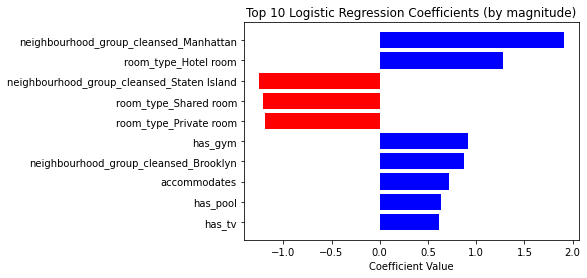

In [ ]:
# interpret my model's outputs
# get coefficients for each feature
feature_imp = best_model.coef_[0]

# create a dataframe of feature names and their coefficients
df_features = pd.DataFrame({'name': X_train.columns.values, 'imp': feature_imp})

# sort by absolute value of coefficient, descending
df_sorted = df_features.reindex(df_features['imp'].abs().sort_values(ascending=False).index)

# extract top 5 feature names
top_five = df_sorted.iloc[:5]['name'].tolist()
print('Top 5 most influential features:', top_five)
print(df_sorted.head(5))

# plot top 10 coefficients by absolute value
top_ten = df_sorted.iloc[:10]
colors = ['red' if v < 0 else 'blue' for v in top_ten['imp']]
plt.barh(top_ten['name'], top_ten['imp'], color=colors)
plt.xlabel('Coefficient Value')
plt.title('Top 10 Logistic Regression Coefficients (by magnitude)')
plt.gca().invert_yaxis()
plt.show()

### Model Reflection:

1. Which model did I choose and why?
2. What did I learn through the model selection process?
3. How do I interpret my model's outputs?
4. Are there any fairness or ethical concerns with my model?

1. I chose logistic regression because this is a binary classification problem, and logistic regression handles binary outcomes well. Logistic regression also produces interpretable coefficients. This makes it easier to explain which features drive predictions to Trove Analytics.
2. When I did grid search, the performance of the tuned model was nearly identical to the untuned version. Both had an accuracy of 0.7590636597202398 and F1 score of 0.6268788682581786. This is because the default hyperparameters were already near-optimal. I found that tuning the classification threshold was a more useful mechanism for improving F1 given the class imbalance. I selected the threshold using only the training set.
3. The top 5 features were 'neighbourhood_group_cleansed_Manhattan', 'room_type_Hotel room', 'neighbourhood_group_cleansed_Staten Island', 'room_type_Shared room', and 'room_type_Private room'. Manhattan listings and hotel rooms are strongly associated with high prices. Staten Island listings, shared rooms, and private rooms are strongly associated with low prices.
4. There are some fairness and ethical concerns with my model. 'neighbourhood_group_cleansed' was the strongest predictor, but location can act as a proxy for socioeconomic status as well as, in some cases, race or ethnicity. This means that my model relies heavily on where a listing is rather than its actual qualities. This could cause it to systematically undervalue listings in lower-income or minority-majority neighborhoods undeservingly. This could reduce investment interest in those areas regardless of listing quality, disproportionately harming hosts there. 

---
## Part 6: Train, Test, Evaluate and Improve a Neural Network

### Prepare My Data for the Neural Network

In [ ]:
# scale data for the neural network

# create the scaler
scaler = StandardScaler()

# fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)

### Step 1: Define My Model Architecture

In [ ]:
# get the number of features in my training data
n_features = X_train_scaled.shape[1]

# create the neural network model
nn_model = keras.Sequential()

# create the input layer and add the input layer to the 'nn_model' object
input_layer = keras.layers.InputLayer(input_shape=n_features)
nn_model.add(input_layer)

# create the hidden layers and add the hidden layers to the 'nn_model' object
hidden_layer_1 = keras.layers.Dense(units=16, activation='relu')
nn_model.add(hidden_layer_1)

hidden_layer_2 = keras.layers.Dense(units=8, activation='relu')
nn_model.add(hidden_layer_2)

# 2 hidden layers: enough to caputre the non-linear patterns without overfitting
# decrease by factor of 2 for units: starting at 8 units and narrowing down lets the model narrow from abstract to more compact before the output layer
    # tested with 16 and 8 units, led to overfitting, switched to 8 and 4 units respectively
# ReLU activation function: trains efficiently, avoids vanishing gradient issues that sigmoid/tanh can cause


# create the output layer and add the output layer to the 'nn_model' object
output_layer = keras.layers.Dense(units=1, activation='sigmoid')
nn_model.add(output_layer)

# print a summary of my model
nn_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 16)                512       
_________________________________________________________________
dense_1 (Dense)              (None, 8)                 136       
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 9         
Total params: 657
Trainable params: 657
Non-trainable params: 0
_________________________________________________________________


### Step 2:  Define the Optimization Function

In [ ]:
sgd_optimizer = keras.optimizers.SGD(learning_rate=0.01)
# learning_rate=0.01: small enough to avoid overshooting the minimum, large enough to converge in a reasonable number of epochs

### Step 3: Define the Loss Function

In [21]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

### Step 4: Compile the Model

In [22]:
nn_model.compile(optimizer=sgd_optimizer, loss=loss_fn, metrics=['accuracy'])

### Step 5: Fit the Model to the Training Data

In [23]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


In [ ]:
# num_epochs = 100: gives the model enough passes over the training data to converge without overfitting

t0 = time.time() # start time

num_epochs = 30

history = nn_model.fit(X_train_scaled, y_train, epochs=num_epochs, validation_split=0.2, verbose=0, callbacks=[ProgBarLoggerNEpochs(num_epochs, every_n=5)])

t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

Epoch [5/ 30], Loss: 0.3932, Accuracy: 0.8160, Val_loss: 0.3925, Val_accuracy: 0.8149
Epoch [10/ 30], Loss: 0.3742, Accuracy: 0.8249, Val_loss: 0.3782, Val_accuracy: 0.8197
Epoch [15/ 30], Loss: 0.3642, Accuracy: 0.8317, Val_loss: 0.3703, Val_accuracy: 0.8240
Epoch [20/ 30], Loss: 0.3579, Accuracy: 0.8363, Val_loss: 0.3655, Val_accuracy: 0.8254
Epoch [25/ 30], Loss: 0.3538, Accuracy: 0.8374, Val_loss: 0.3617, Val_accuracy: 0.8280
Epoch [30/ 30], Loss: 0.3502, Accuracy: 0.8393, Val_loss: 0.3595, Val_accuracy: 0.8290
Elapsed time: 71.04s


### Step 6: Visualize Training Performance


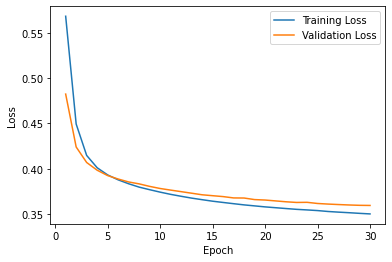

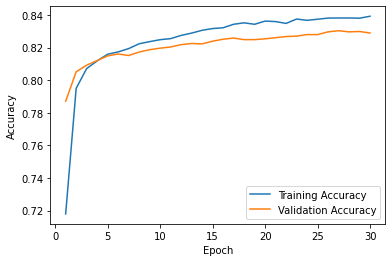

In [ ]:
# plot training loss and validation loss over epochs
plt.plot(range(1, num_epochs+1), history.history['loss'], label='Training Loss')
plt.plot(range(1, num_epochs+1), history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# plot training accuracy and validation accuracy over epochs
plt.plot(range(1, num_epochs+1), history.history['accuracy'], label='Training Accuracy')
plt.plot(range(1, num_epochs+1), history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### Step 7: Evaluate the Model's Performance on the Test Set

In [ ]:
# generate predictions from neural network using scaled test data
# nn_model.predict() returns probabilities — apply a threshold of 0.5 to get class labels

probability_predictions = nn_model.predict(X_test_scaled)
class_label_predictions = (probability_predictions >= 0.5).astype(int)

In [ ]:
# compute accuracy and F1 score for the neural network and print the results

nn_test_accuracy = accuracy_score(y_test, class_label_predictions)
nn_test_f1 = f1_score(y_test, class_label_predictions)

print("Neural Network Test Accuracy: ", nn_test_accuracy)
print("Neural Network Test F1 Score: ", nn_test_f1)

Neural Network Test Accuracy:  0.8330002854695975
Neural Network Test F1 Score:  0.6404425322679779


#### Neural Network Reflection:

1. Walk through the architecture decisions. Why did I make each of those choices?
2. What did my training curves tell me?
3. How did my neural network perform on the test set?

1. I used 2 hidden layers of 16 and 8 units with ReLU activation, with a sigmoid output layer for binary classification. I tried a smaller version with 8 and 4 units, but it slightly underfit, so I went back to 16 and 8 units. I used SGD with a learning rate of 0.01 because I thought it was a good standard default. I trained the model for 30 epochs. I initiall used 100 epochs, but the validation curves showed the model converged by 20-30 epochs, so more epochs was just wasted time without improving results.
2. When I used 100 epochs for 16 and 8 units, I saw mild overfitting, where the training accuracy kept rising while the validation accuracy stayed flat. Shrinking the number of units to 8 and 4 reduced the gap but caused underfitting, as the training accuracy lowered. Going back to 16 and 8 units, I used only 30 epochs to fix the issues. This gave me a small training accuracy and validation accuracy gap and stable metrics by the final epochs.
3. The test set gave an accuracy of about 83.30% and F1 score of 64.04%. The accuracy matched what the training curves predicted. The F1 score was lower than expected, likely due to class imbalance. 

## Part 7: Compare Models and Reflect

###  Results Summary

In [ ]:
results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score'],
    'Logistic Regression': [threshold_acc, threshold_f1],
    'Neural Network': [nn_test_accuracy, nn_test_f1]
})
print(results.to_string(index=False))

   Metric  Logistic Regression  Neural Network
 Accuracy             0.779047        0.833000
 F1 Score             0.628777        0.640443


### Comparative Analysis

1. **Performance comparison.** How did the two models perform relative to each other?

2. **Was the added complexity worth it?** Given the performance difference, will the neural network justify that added complexity for this problem?

3. **Recommendation.** If I were presenting this work to my company and their client as described in the business brief, which model would I recommend deploying and why?

4. **What I would do next.** If I had more time, what would I try to improve my results?

1. The neural network outperformed the logistic regression model on both metrics. Accuracy improved from 77.90% to 83.30% (about 5.4 percentage points), and F1 score improved from 62.88% to 64.04% (about 1.2 percentage points). The F1 improvement was much smaller than the accuracy improvement.
2. The added complexity was particially worth it. If the Trove Analytics needed faster results or results that are easier to interpret, the logistic regression is the better option. If those factors are not so important to Trove Analytics and accuracy is more important, the neural network is the better option. Logistic regression may be better in this case because Trove Analytics will likely want to understand why the model is making the decisions that it does.
3. If I were presenting this to Trove Analytics, I would recommend logistic regression. This is because logistic regression allows for interpretability, which would be important given that Trove Analytics will want to understand and trust the model's reasoning before making decisions involving real money. This will also allow us to interpret the output to see if any bias is present. Also, a false positive is worse than a false negative because a false positive means Trove Analytics loses money. Given that the F1 scores of both models are fairly close, logistic regression doesn't sacrifice much recall, which is important here. Further, logistic regression is faster and simplier.
4. If I had more time, I would do more feature engineering to gain more predictive variables that may have a strong effect on the label. I would also double check with my client whether they want to avoid false negatives or false positives. Perhaps I would also try out a decision tree and compare it to my other models.

---
## AI Use Attestation

Reflection on how I used AI tools during this capstone.

1. Where and at what stages of this capstone did I use AI tools?
2. Identify one part of the capstone that required the most effort or thought. What made it challenging, and how did I work through it, with AI or without AI?
3. How did I verify that my work was correct?
4. What is one thing I would do differently next time?

1. I used AI tools whenever I got stuck during this capstone, which was very useful in helping me optimize the logistic regression model. Sometimes it was difficult to interpret why I was getting a low accuracy score. Inputting my methodology and results into AI helped me understand the best steps to take to improve my model. I also pasted my code into AI when I had a small error such as a typo I could not easily spot, which was very efficient.
2. Performing feature selection required the most thought for me. There were so many features to choose from, so I used AI to recommend tests for me to perform on the data to see which features I should keep, and which I should not. One prompt that worked well was after an AI recommended that I drop the 'amenities' "isn't amenities relevant?" The prompt was helpful because it showed that it is right to push back sometimes on AI because it is not always right. Some of the new columns that I made that were based on the 'amenities' column were of the most influential on the label.
3. I verified that my work was correct by visualizing the results and seeing if it looked appropriate. When I was still unsure, I would give a part that I was was unsure about to an AI tool and ask if I am making any mistakes.
4. One thing I would do differently next time is do more testing on the features before deleting some of them. For instance, for columns that are similar to one another, I would see which one has the strongest effect on the output before deciding which one to keep and which ones to delete.